In [1]:
import pandas as pd
import numpy as np
df=pd.read_excel('/content/Amazon_Customer_Purchase_Data.xlsx')

In [2]:
df

,Customer_ID,Customer_Name,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,John,56.0,Other,New York,Books,674,2020-01-01 00:00:00,491.643012,Cash,NaN,NaN,3673.712747,60,No,No,Regular,In-store
1,10860,Eve,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,144.326722,Cash,5.0,Good,2103.060388,29,Yes,Yes,New,In-store
2,15390,John,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,109.301892,Bank Transfer,NaN,NaN,899.115059,92,No,No,VIP,Online
3,15191,Eve,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,226.655516,Bank Transfer,2.0,Excellent,2591.137716,62,Yes,Yes,Regular,Online
4,15734,Eve,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,37.851880,Bank Transfer,2.0,NaN,548.620397,80,No,Yes,Regular,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,10661,Charlie,61.0,Male,Los Angeles,Home Appliances,989,2020-03-24 03:00:00,168.291356,Credit Card,5.0,Excellent,1058.502176,3,Yes,No,New,Online
1996,13374,Eve,41.0,Female,Chicago,Books,409,2020-03-24 04:00:00,237.252493,Bank Transfer,5.0,Average,1581.739382,79,Yes,No,Regular,Online
1997,19208,Alice,58.0,Female,Houston,Toys,617,2020-03-24 05:00:00,213.388283,PayPal,4.0,Good,1155.797595,76,Yes,No,Regular,In-store
1998,10207,John,18.0,Female,San Francisco,Books,113,2020-03-24 06:00:00,83.056883,Bank Transfer,2.0,NaN,1155.489570,32,No,No,New,Online


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Customer_Name               1900 non-null   object        
 2   Age                         1900 non-null   float64       
 3   Gender                      2000 non-null   object        
 4   Location                    2000 non-null   object        
 5   Product_Category            2000 non-null   object        
 6   Product_ID                  2000 non-null   int64         
 7   Purchase_Date               2000 non-null   datetime64[ns]
 8   Purchase_Amount             1800 non-null   float64       
 9   Payment_Method              2000 non-null   object        
 10  Rating                      1860 non-null   float64       
 11  Feedback_Comments           1099 non-null   object      

In [4]:
df.drop('Customer_Name', inplace=True, axis=1)

In [5]:
df.fillna(df.select_dtypes(['int64', 'float64']).mean(), inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Age                         2000 non-null   float64       
 2   Gender                      2000 non-null   object        
 3   Location                    2000 non-null   object        
 4   Product_Category            2000 non-null   object        
 5   Product_ID                  2000 non-null   int64         
 6   Purchase_Date               2000 non-null   datetime64[ns]
 7   Purchase_Amount             2000 non-null   float64       
 8   Payment_Method              2000 non-null   object        
 9   Rating                      2000 non-null   float64       
 10  Feedback_Comments           1099 non-null   object        
 11  Customer_Lifetime_Value     2000 non-null   float64     

In [7]:
for i in df.select_dtypes('object').columns:
  df[i].fillna(df[i].mode()[0], inplace=True)

/tmp/ipython-input-7-3815325728.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0], inplace=True)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Age                         2000 non-null   float64       
 2   Gender                      2000 non-null   object        
 3   Location                    2000 non-null   object        
 4   Product_Category            2000 non-null   object        
 5   Product_ID                  2000 non-null   int64         
 6   Purchase_Date               2000 non-null   datetime64[ns]
 7   Purchase_Amount             2000 non-null   float64       
 8   Payment_Method              2000 non-null   object        
 9   Rating                      2000 non-null   float64       
 10  Feedback_Comments           2000 non-null   object        
 11  Customer_Lifetime_Value     2000 non-null   float64     

In [9]:
df.describe()

,Customer_ID,Age,Product_ID,Purchase_Date,Purchase_Amount,Rating,Customer_Lifetime_Value,Loyalty_Score
count,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.00000
mean,15022.171500,43.696316,546.669000,2020-02-11 15:29:59.999999744,257.954370,2.978495,2566.724026,51.45700
min,10001.000000,18.000000,100.000000,2020-01-01 00:00:00,10.077295,1.000000,56.153142,1.00000
25%,12585.750000,32.000000,320.750000,2020-01-21 19:45:00,151.383179,2.000000,1349.598107,26.00000
50%,15104.500000,43.696316,551.000000,2020-02-11 15:30:00,257.954370,3.000000,2559.658142,52.00000
75%,17408.250000,56.000000,763.000000,2020-03-03 11:15:00,367.247567,4.000000,3475.870962,76.00000
max,19998.000000,69.000000,998.000000,2020-03-24 07:00:00,499.839871,5.000000,7204.408434,100.00000
std,2865.577794,14.525405,259.999847,NaN,134.915732,1.359225,1568.100325,28.74591


In [10]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

In [11]:
df.head(15)

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,56.0,Other,New York,Books,674,2020-01-01 00:00:00,491.643012,Cash,2.978495,Good,3673.712747,60,No,No,Regular,In-store
1,10860,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,144.326722,Cash,5.000000,Good,2103.060388,29,Yes,Yes,New,In-store
2,15390,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,109.301892,Bank Transfer,2.978495,Good,899.115059,92,No,No,VIP,Online
3,15191,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,226.655516,Bank Transfer,2.000000,Excellent,2591.137716,62,Yes,Yes,Regular,Online
4,15734,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,37.851880,Bank Transfer,2.000000,Good,548.620397,80,No,Yes,Regular,Both
5,16265,26.0,Other,New York,Clothing,279,2020-01-01 05:00:00,489.462288,PayPal,3.000000,Good,2727.555899,46,No,No,Regular,Online
6,10466,23.0,Female,New York,Clothing,139,2020-01-01 06:00:00,298.332443,PayPal,4.000000,Good,3076.554423,26,No,No,New,Both
7,14426,68.0,Other,Chicago,Books,875,2020-01-01 07:00:00,282.906525,Bank Transfer,4.000000,Bad,3269.745729,28,No,No,New,Online
8,15578,62.0,Other,Chicago,Electronics,800,2020-01-01 08:00:00,331.340177,Credit Card,2.000000,Good,4319.156456,92,Yes,No,VIP,Online
9,18322,52.0,Male,San Francisco,Books,619,2020-01-01 09:00:00,253.541587,Credit Card,3.000000,Average,3428.350802,59,No,No,Regular,Both


In [12]:
for i in df.select_dtypes('object').columns:
  print(f"{i} distibution is")
  print('-------------------------')
  print(df[i].value_counts())
  print("============================================")

Gender distibution is
-------------------------
Gender
Female    687
Male      662
Other     651
Name: count, dtype: int64
Location distibution is
-------------------------
Location
New York         434
San Francisco    430
Los Angeles      381
Chicago          379
Houston          376
Name: count, dtype: int64
Product_Category distibution is
-------------------------
Product_Category
Toys               437
Home Appliances    397
Electronics        395
Books              392
Clothing           379
Name: count, dtype: int64
Payment_Method distibution is
-------------------------
Payment_Method
Credit Card      509
Cash             506
PayPal           501
Bank Transfer    484
Name: count, dtype: int64
Feedback_Comments distibution is
-------------------------
Feedback_Comments
Good         1191
Excellent     271
Average       270
Bad           268
Name: count, dtype: int64
Discount_Applied distibution is
-------------------------
Discount_Applied
No     1397
Yes     603
Name: count, dty

In [13]:
#Standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df[['Purchase_Amount','Customer_Lifetime_Value']]=sc.fit_transform(df[['Purchase_Amount','Customer_Lifetime_Value']])

In [14]:
df

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,56.0,Other,New York,Books,674,2020-01-01 00:00:00,1.732541,Cash,2.978495,Good,0.706119,60,No,No,Regular,In-store
1,10860,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,-0.842423,Cash,5.000000,Good,-0.295759,29,Yes,Yes,New,In-store
2,15390,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,-1.102093,Bank Transfer,2.978495,Good,-1.063724,92,No,No,VIP,Online
3,15191,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,-0.232046,Bank Transfer,2.000000,Excellent,0.015573,62,Yes,Yes,Regular,Online
4,15734,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,-1.631815,Bank Transfer,2.000000,Good,-1.287295,80,No,Yes,Regular,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,10661,61.0,Male,Los Angeles,Home Appliances,989,2020-03-24 03:00:00,-0.664752,Credit Card,5.000000,Excellent,-0.962055,3,Yes,No,New,Online
1996,13374,41.0,Female,Chicago,Books,409,2020-03-24 04:00:00,-0.153481,Bank Transfer,5.000000,Average,-0.628296,79,Yes,No,Regular,Online
1997,19208,58.0,Female,Houston,Toys,617,2020-03-24 05:00:00,-0.330408,PayPal,4.000000,Good,-0.899993,76,Yes,No,Regular,In-store
1998,10207,18.0,Female,San Francisco,Books,113,2020-03-24 06:00:00,-1.296670,Bank Transfer,2.000000,Good,-0.900189,32,No,No,New,Online


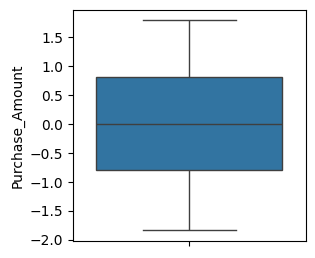

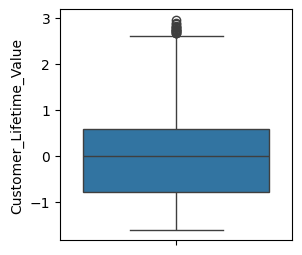

In [15]:
#for outlier detection
import matplotlib.pyplot as plt
import seaborn as sns
for i in ['Purchase_Amount','Customer_Lifetime_Value']:
  plt.figure(figsize=(3,3))
  sns.boxplot(y = i, data= df)

In [16]:
#outlier treatment for Purchase amount and CLV
for i in ['Purchase_Amount','Customer_Lifetime_Value']:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-(1.5*IQR)
  upper=Q3+(1.5*IQR)
  med=df[i].median()
  df[i]=np.where((df[i]<lower) | (df[i]>upper),med,df[i])
  print(i,lower,upper)

Purchase_Amount -3.1906983673150915 3.2108790121939745
Customer_Lifetime_Value -2.8108132998283297 2.614361579738905


In [17]:
# Droping the unuseful column
df.drop_duplicates(subset=['Customer_ID', 'Purchase_Date'], inplace=True)

In [18]:
df

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,56.0,Other,New York,Books,674,2020-01-01 00:00:00,1.732541,Cash,2.978495,Good,0.706119,60,No,No,Regular,In-store
1,10860,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,-0.842423,Cash,5.000000,Good,-0.295759,29,Yes,Yes,New,In-store
2,15390,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,-1.102093,Bank Transfer,2.978495,Good,-1.063724,92,No,No,VIP,Online
3,15191,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,-0.232046,Bank Transfer,2.000000,Excellent,0.015573,62,Yes,Yes,Regular,Online
4,15734,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,-1.631815,Bank Transfer,2.000000,Good,-1.287295,80,No,Yes,Regular,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,10661,61.0,Male,Los Angeles,Home Appliances,989,2020-03-24 03:00:00,-0.664752,Credit Card,5.000000,Excellent,-0.962055,3,Yes,No,New,Online
1996,13374,41.0,Female,Chicago,Books,409,2020-03-24 04:00:00,-0.153481,Bank Transfer,5.000000,Average,-0.628296,79,Yes,No,Regular,Online
1997,19208,58.0,Female,Houston,Toys,617,2020-03-24 05:00:00,-0.330408,PayPal,4.000000,Good,-0.899993,76,Yes,No,Regular,In-store
1998,10207,18.0,Female,San Francisco,Books,113,2020-03-24 06:00:00,-1.296670,Bank Transfer,2.000000,Good,-0.900189,32,No,No,New,Online


In [19]:
## Lable encoding
from sklearn.preprocessing import LabelEncoder
for i in df.select_dtypes('object').columns:
  le=LabelEncoder()
  df[i]=le.fit_transform(df[i])

In [ ]:
df['Rating'] = df['Rating'].round(0).astype(int)
df['Age'] = df['Age'].round(0).astype(int)
df.head()

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,56.0,2,3,0,674,2020-01-01 00:00:00,1.732541,1,3,3,0.706119,60,0,0,1,1
1,10860,33.0,2,1,3,393,2020-01-01 01:00:00,-0.842423,1,5,3,-0.295759,29,1,1,0,1
2,15390,50.0,0,1,1,995,2020-01-01 02:00:00,-1.102093,0,3,3,-1.063724,92,0,0,2,2
3,15191,66.0,2,4,2,405,2020-01-01 03:00:00,-0.232046,0,2,2,0.015573,62,1,1,1,2
4,15734,38.0,0,3,4,353,2020-01-01 04:00:00,-1.631815,0,2,3,-1.287295,80,0,1,1,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Age                         2000 non-null   float64       
 2   Gender                      2000 non-null   int64         
 3   Location                    2000 non-null   int64         
 4   Product_Category            2000 non-null   int64         
 5   Product_ID                  2000 non-null   int64         
 6   Purchase_Date               2000 non-null   datetime64[ns]
 7   Purchase_Amount             2000 non-null   float64       
 8   Payment_Method              2000 non-null   int64         
 9   Rating                      2000 non-null   int64         
 10  Feedback_Comments           2000 non-null   int64         
 11  Customer_Lifetime_Value     2000 non-null   float64     

In [22]:
# Projected Customer_Lifetime_Value (CLV)
df['CLV_Estimated'] = (df['Customer_Lifetime_Value'] * df['Loyalty_Score']) / 100
df.head()

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel,CLV_Estimated
0,17270,56.0,2,3,0,674,2020-01-01 00:00:00,1.732541,1,3,3,0.706119,60,0,0,1,1,0.423671
1,10860,33.0,2,1,3,393,2020-01-01 01:00:00,-0.842423,1,5,3,-0.295759,29,1,1,0,1,-0.085770
2,15390,50.0,0,1,1,995,2020-01-01 02:00:00,-1.102093,0,3,3,-1.063724,92,0,0,2,2,-0.978626
3,15191,66.0,2,4,2,405,2020-01-01 03:00:00,-0.232046,0,2,2,0.015573,62,1,1,1,2,0.009655
4,15734,38.0,0,3,4,353,2020-01-01 04:00:00,-1.631815,0,2,3,-1.287295,80,0,1,1,0,-1.029836


In [23]:
# Loyalty Score
df['Loyalty_Score_Enhanced'] = ((df['Purchase_Amount'] / df['Purchase_Amount'].max()) * 50 + (df['Rating'] / df['Rating'].max()) * 50).round().astype(int)
df.head()

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel,CLV_Estimated,Loyalty_Score_Enhanced
0,17270,56.0,2,3,0,674,2020-01-01 00:00:00,1.732541,1,3,3,0.706119,60,0,0,1,1,0.423671,78
1,10860,33.0,2,1,3,393,2020-01-01 01:00:00,-0.842423,1,5,3,-0.295759,29,1,1,0,1,-0.085770,27
2,15390,50.0,0,1,1,995,2020-01-01 02:00:00,-1.102093,0,3,3,-1.063724,92,0,0,2,2,-0.978626,-1
3,15191,66.0,2,4,2,405,2020-01-01 03:00:00,-0.232046,0,2,2,0.015573,62,1,1,1,2,0.009655,14
4,15734,38.0,0,3,4,353,2020-01-01 04:00:00,-1.631815,0,2,3,-1.287295,80,0,1,1,0,-1.029836,-25


In [24]:
# Customer Segment
df['Customer_Segment_Label'] = pd.cut( df['Loyalty_Score'], bins=[0, 39, 74, 100], labels=['New', 'Regular', 'VIP'])
df.head()

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel,CLV_Estimated,Loyalty_Score_Enhanced,Customer_Segment_Label
0,17270,56.0,2,3,0,674,2020-01-01 00:00:00,1.732541,1,3,3,0.706119,60,0,0,1,1,0.423671,78,Regular
1,10860,33.0,2,1,3,393,2020-01-01 01:00:00,-0.842423,1,5,3,-0.295759,29,1,1,0,1,-0.085770,27,New
2,15390,50.0,0,1,1,995,2020-01-01 02:00:00,-1.102093,0,3,3,-1.063724,92,0,0,2,2,-0.978626,-1,VIP
3,15191,66.0,2,4,2,405,2020-01-01 03:00:00,-0.232046,0,2,2,0.015573,62,1,1,1,2,0.009655,14,Regular
4,15734,38.0,0,3,4,353,2020-01-01 04:00:00,-1.631815,0,2,3,-1.287295,80,0,1,1,0,-1.029836,-25,VIP


In [25]:
segment = {'New': 0 ,'Regular': 1,'VIP': 2}
df['Customer_Segment_Label'] = df['Customer_Segment_Label'].map(segment)

In [26]:
df.head()

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel,CLV_Estimated,Loyalty_Score_Enhanced,Customer_Segment_Label
0,17270,56.0,2,3,0,674,2020-01-01 00:00:00,1.732541,1,3,3,0.706119,60,0,0,1,1,0.423671,78,1
1,10860,33.0,2,1,3,393,2020-01-01 01:00:00,-0.842423,1,5,3,-0.295759,29,1,1,0,1,-0.085770,27,0
2,15390,50.0,0,1,1,995,2020-01-01 02:00:00,-1.102093,0,3,3,-1.063724,92,0,0,2,2,-0.978626,-1,2
3,15191,66.0,2,4,2,405,2020-01-01 03:00:00,-0.232046,0,2,2,0.015573,62,1,1,1,2,0.009655,14,1
4,15734,38.0,0,3,4,353,2020-01-01 04:00:00,-1.631815,0,2,3,-1.287295,80,0,1,1,0,-1.029836,-25,2


In [ ]:
df.to_excel('/content/CleanedDataWithNewFeatures.xlsx', index=False)